# Day 9: Monitoring, Drift & Retraining Plan

Deployment is not the end of a machine learning project.

Fraud behaviour changes over time. A model trained on old behaviour may become less reliable when new behaviour appears. Monitoring helps detect when live transactions start to look different from the training or reference data. Retraining helps the model adapt to new fraud tactics.

## Day 9 Workflow

```text
Raw / processed transaction data
down to
Create reference and current periods
down to
Compare data distributions
down to
Detect drift with EvidentlyAI
down to
Create fallback manual drift summary
down to
Monitor model performance
down to
Flag performance decay
down to
Define escalation rules
down to
Create retraining playbook
```


## 1. Import Libraries

This section imports the tools used for monitoring.

EvidentlyAI changes its Python API across versions. Evidently 0.7+ no longer supports some older examples such as `from evidently.report import Report`. This notebook first imports the installed `evidently` package directly, prints the installed version, then tries the Evidently 0.7+ API before trying older compatibility patterns.

If Evidently cannot create an HTML report, the notebook does not crash. It logs the reason and keeps the pandas manual drift checks as transparent monitoring evidence.


In [37]:
from pathlib import Path
import json
import shutil
import warnings
from importlib import metadata

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
except Exception as exc:
    plt = None
    print(f"matplotlib is unavailable: {exc}")

try:
    import seaborn as sns
except Exception as exc:
    sns = None
    print(f"seaborn is unavailable: {exc}")

try:
    import joblib
except Exception as exc:
    joblib = None
    print(f"joblib is unavailable: {exc}")

warnings.filterwarnings("ignore")

EVIDENTLY_AVAILABLE = False
EVIDENTLY_VERSION = None
EVIDENTLY_IMPORT_STATUS = {
    "installed": False,
    "version": None,
    "package_import_error": None,
    "version_detection_error": None,
}

try:
    import evidently
    EVIDENTLY_AVAILABLE = True
    EVIDENTLY_IMPORT_STATUS["installed"] = True

    EVIDENTLY_VERSION = getattr(evidently, "__version__", None)
    if EVIDENTLY_VERSION is None:
        try:
            EVIDENTLY_VERSION = metadata.version("evidently")
        except Exception as version_exc:
            EVIDENTLY_IMPORT_STATUS["version_detection_error"] = str(version_exc)
            EVIDENTLY_VERSION = "unknown"

    EVIDENTLY_IMPORT_STATUS["version"] = EVIDENTLY_VERSION
    print(f"EvidentlyAI package detected. Installed version: {EVIDENTLY_VERSION}")
except ModuleNotFoundError as exc:
    evidently = None
    EVIDENTLY_IMPORT_STATUS["package_import_error"] = str(exc)
    print("EvidentlyAI package is missing. Install with: pip install evidently")
except Exception as exc:
    evidently = None
    EVIDENTLY_IMPORT_STATUS["package_import_error"] = str(exc)
    print("EvidentlyAI package import failed for a reason other than missing installation.")
    print(f"Import detail: {exc}")


EvidentlyAI package detected. Installed version: 0.7.21


## 2. Create Output Folders

The notebook creates three Day 9 output folders:

- `reports/artifacts/day9/` stores CSV and JSON monitoring outputs.
- `reports/figures/day9/` stores visual charts.
- `reports/monitoring/day9/` stores EvidentlyAI HTML reports.

Keeping these outputs separate makes the monitoring evidence easy to review without changing earlier Day 8 API files.


In [38]:
PROJECT_ROOT = Path.cwd()
ARTIFACT_DIR = PROJECT_ROOT / "reports" / "artifacts" / "day9"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures" / "day9"
MONITORING_DIR = PROJECT_ROOT / "reports" / "monitoring" / "day9"

for folder in [ARTIFACT_DIR, FIGURE_DIR, MONITORING_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Artifacts:", ARTIFACT_DIR)
print("Figures:", FIGURE_DIR)
print("Monitoring reports:", MONITORING_DIR)


Project root: C:\Users\sadeq
Artifacts: C:\Users\sadeq\reports\artifacts\day9
Figures: C:\Users\sadeq\reports\figures\day9
Monitoring reports: C:\Users\sadeq\reports\monitoring\day9


## 3. Load Data Robustly

The notebook loads the first available dataset in this order:

1. `data/processed/feature_engineered_transactions.csv`
2. `data/processed/cleaned_transactions.csv`
3. `data/raw/nova_pay_combined.csv`

After loading the data, we show the shape, first rows, column list, missing values, class distribution, and timestamp range. These checks matter because monitoring depends on knowing what data exists, how complete it is, and whether fraud labels are available.


In [39]:
DATA_CANDIDATES = [
    PROJECT_ROOT / "data" / "processed" / "feature_engineered_transactions.csv",
    PROJECT_ROOT / "data" / "processed" / "cleaned_transactions.csv",
    PROJECT_ROOT / "data" / "raw" / "nova_pay_combined.csv",
]

selected_data_path = next((path for path in DATA_CANDIDATES if path.exists()), None)
if selected_data_path is None:
    raise FileNotFoundError("No NovaPay dataset found in data/processed or data/raw.")

df = pd.read_csv(selected_data_path)
print("Loaded dataset:", selected_data_path)
print("Dataset shape:", df.shape)
display(df.head())
print("Columns:")
print(list(df.columns))

missing_summary = (
    df.isna().mean().mul(100).round(2)
    .rename("missing_rate_percent")
    .reset_index()
    .rename(columns={"index": "column"})
)
display(missing_summary)
missing_summary.to_csv(ARTIFACT_DIR / "missing_value_summary.csv", index=False)

if "is_fraud" in df.columns:
    class_distribution = df["is_fraud"].value_counts(dropna=False).rename_axis("is_fraud").reset_index(name="count")
    class_distribution["share"] = class_distribution["count"] / len(df)
    display(class_distribution)
    class_distribution.to_csv(ARTIFACT_DIR / "class_distribution.csv", index=False)
else:
    print("No is_fraud label column found. Full performance monitoring will be limited.")

if "timestamp" in df.columns:
    timestamp = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
    print("Timestamp range:", timestamp.min(), "to", timestamp.max())
else:
    print("No timestamp column found. The notebook will use row order for the reference/current split.")


Loaded dataset: C:\Users\sadeq\data\processed\feature_engineered_transactions.csv
Dataset shape: (10940, 52)


,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,customer_recency_days,device_transaction_count,device_avg_trust_score,device_trust_band,high_velocity_1h_flag,high_velocity_24h_flag,any_velocity_risk_flag,high_ip_risk_flag,low_device_trust_flag,chargeback_group
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,atm,278.19,278.19,4.25,...,16.756991,7,0.500571,Medium,0,0,0,0,0,No Chargeback
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,59.824016,3,0.575000,Medium,0,0,0,0,0,No Chargeback
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.000000,22,0.932182,Very High,0,0,0,0,0,No Chargeback
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,74.644699,21,0.543857,Medium,0,0,0,0,0,No Chargeback
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,37.192859,34,0.889455,Very High,0,0,0,0,0,No Chargeback


Columns:
['transaction_id', 'customer_id', 'timestamp', 'home_country', 'source_currency', 'dest_currency', 'channel', 'amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'device_id', 'new_device', 'ip_address', 'ip_country', 'location_mismatch', 'ip_risk_score', 'kyc_tier', 'account_age_days', 'device_trust_score', 'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'is_fraud', 'transaction_hour', 'weekday', 'weekday_name', 'is_weekend', 'is_night_transaction', 'country_mismatch_flag', 'corridor', 'corridor_risk_band', 'customer_transaction_count', 'customer_total_amount', 'customer_avg_amount', 'customer_max_amount', 'customer_amount_std', 'customer_first_txn', 'customer_last_txn', 'amount_to_customer_avg', 'customer_recency_days', 'device_transaction_count', 'device_avg_trust_score', 'device_trust_band', 'high_velocity_1h_flag', 'high_velocity_24h_flag', 'any_velocity_risk_flag', 'high_ip_risk_flag', 'low_device_trus

,column,missing_rate_percent
0,transaction_id,0.00
1,customer_id,0.00
2,timestamp,0.00
3,home_country,0.00
4,source_currency,0.00
5,dest_currency,0.00
6,channel,0.00
7,amount_src,0.00
8,amount_usd,2.65
9,fee,2.65


,is_fraud,count,share
0,0,9951,0.909598
1,1,989,0.090402


Timestamp range: 2022-10-03 18:40:59.468549+00:00 to 2025-12-16 00:13:41.468549+00:00


### How to Read These Data Checks

- **Shape** tells us how many rows and columns we can monitor.
- **First rows** confirm that the data loaded correctly.
- **Columns** show which monitoring features are available.
- **Class distribution** shows how common fraud is, if labels exist.
- **Timestamp range** helps us split older reference data from newer current data.

### Why Missing Values Matter After Deployment

Missing values are monitored after deployment because production data can change.

Example:

```text
During training:    ip_risk_score missing = 0%
After deployment:  ip_risk_score missing = 20%
```

Possible causes include a data pipeline failure, a third-party provider issue, new customer behaviour, or new fraud behaviour. A sudden missing-value increase is a drift signal because the model may be receiving weaker or incomplete inputs than it saw during training.


## 4. Create Reference and Current Datasets

Reference data is historical transaction behaviour the model understands.

Current data is newer transaction behaviour after deployment.

The goal is not to clean the data again. The goal is to detect whether current transactions are becoming different from the historical or training-like transactions. Drift monitoring compares these two periods so NovaPay can see when the model environment is changing.


In [40]:
work_df = df.copy()
if "timestamp" in work_df.columns:
    work_df["timestamp"] = pd.to_datetime(work_df["timestamp"], errors="coerce", utc=True)
    work_df = work_df.sort_values("timestamp", na_position="last").reset_index(drop=True)
    split_method = "timestamp"
else:
    work_df = work_df.reset_index(drop=True)
    split_method = "row_order"

split_index = int(len(work_df) * 0.70)
reference_df = work_df.iloc[:split_index].copy()
current_df = work_df.iloc[split_index:].copy()

print("Split method:", split_method)
print("Reference rows:", reference_df.shape[0])
print("Current rows:", current_df.shape[0])

reference_df.describe(include="all").transpose().reset_index().rename(columns={"index": "column"}).to_csv(
    ARTIFACT_DIR / "reference_summary.csv", index=False
)
current_df.describe(include="all").transpose().reset_index().rename(columns={"index": "column"}).to_csv(
    ARTIFACT_DIR / "current_summary.csv", index=False
)
print("Saved reference_summary.csv and current_summary.csv")


Split method: timestamp
Reference rows: 7657
Current rows: 3283
Saved reference_summary.csv and current_summary.csv


## 5. Select Monitoring Features

These features are important fraud behaviour signals. Drift in these columns may indicate new fraud tactics or normal customer behaviour changes.

For example:

- A rise in `ip_risk_score` may indicate riskier network environments.
- A drop in `device_trust_score` may indicate more suspicious devices.
- A jump in `txn_velocity_24h` may indicate rapid repeated transaction attempts.
- Changes in corridors or countries may show fraud moving to new routes.


In [41]:
NUMERICAL_CANDIDATES = [
    "amount_usd", "amount_src", "fee", "account_age_days", "ip_risk_score",
    "device_trust_score", "risk_score_internal", "txn_velocity_1h", "txn_velocity_24h",
    "corridor_risk", "transaction_hour", "weekday", "customer_transaction_count",
    "customer_avg_amount", "customer_total_amount", "customer_recency_days",
    "device_transaction_count", "device_avg_trust_score",
]
CATEGORICAL_CANDIDATES = [
    "home_country", "ip_country", "source_currency", "dest_currency", "channel",
    "kyc_tier", "corridor", "corridor_risk_band", "device_trust_band",
    "chargeback_group", "is_weekend", "is_night_transaction", "location_mismatch", "new_device",
]

numerical_features = [col for col in NUMERICAL_CANDIDATES if col in work_df.columns]
categorical_features = [col for col in CATEGORICAL_CANDIDATES if col in work_df.columns]
monitoring_features = numerical_features + categorical_features

reference_monitoring = reference_df[monitoring_features].copy()
current_monitoring = current_df[monitoring_features].copy()

print("Numerical monitoring features:", numerical_features)
print("Categorical monitoring features:", categorical_features)
print("Total monitoring features:", len(monitoring_features))


Numerical monitoring features: ['amount_usd', 'amount_src', 'fee', 'account_age_days', 'ip_risk_score', 'device_trust_score', 'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'transaction_hour', 'weekday', 'customer_transaction_count', 'customer_avg_amount', 'customer_total_amount', 'customer_recency_days', 'device_transaction_count', 'device_avg_trust_score']
Categorical monitoring features: ['home_country', 'ip_country', 'source_currency', 'dest_currency', 'channel', 'kyc_tier', 'corridor', 'corridor_risk_band', 'device_trust_band', 'chargeback_group', 'is_weekend', 'is_night_transaction', 'location_mismatch', 'new_device']
Total monitoring features: 32


## 6. Generate EvidentlyAI Data Drift Report

This section attempts to use EvidentlyAI to create:

`reports/monitoring/day9/data_drift_report.html`

EvidentlyAI compares the statistical distribution of old and new data. The HTML report is useful because it gives visual evidence of drift. If the report is created successfully, users can open it in a browser.

Important beginner note: EvidentlyAI API versions differ. Evidently 0.7+ does not always support older imports such as `from evidently.report import Report`. This notebook separates two cases:

- **Package missing:** Evidently is not installed.
- **Package installed but API changed:** Evidently exists, but a specific report-building method failed.

The notebook first tries the Evidently 0.7+ API and saves HTML from the object returned by `report.run()` when possible. If Evidently changes again, the notebook logs the failure and continues with pandas manual drift monitoring.


In [42]:
def _try_save_evidently_json(report_object, json_path):
    """Best-effort JSON export because Evidently result objects differ by version."""
    json_errors = []
    for method_name in ["as_dict", "dict"]:
        if hasattr(report_object, method_name):
            try:
                result = getattr(report_object, method_name)()
                with open(json_path, "w", encoding="utf-8") as f:
                    json.dump(result, f, indent=2, default=str)
                return True, None
            except Exception as exc:
                json_errors.append(f"{method_name}: {exc}")
    if hasattr(report_object, "json"):
        try:
            raw_json = report_object.json()
            with open(json_path, "w", encoding="utf-8") as f:
                f.write(raw_json if isinstance(raw_json, str) else json.dumps(raw_json, indent=2, default=str))
            return True, None
        except Exception as exc:
            json_errors.append(f"json: {exc}")
    return False, "; ".join(json_errors) if json_errors else "No JSON export method found."


def _save_evidently_html(save_candidates, html_path):
    """Save HTML from the first object that supports Evidently HTML export."""
    errors = []
    for object_name, candidate in save_candidates:
        if candidate is None:
            continue
        for method_name in ["save_html", "save"]:
            if hasattr(candidate, method_name):
                try:
                    getattr(candidate, method_name)(str(html_path))
                    return html_path.exists(), object_name, method_name, None
                except Exception as exc:
                    errors.append(f"{object_name}.{method_name}: {exc}")
    return False, None, None, "; ".join(errors) if errors else "No object exposed save_html or save."


def _run_evidently_report_attempt(attempt_name, report_factory, reference_data, current_data, html_path, json_path):
    """Run one Evidently report attempt and return detailed status."""
    status = {
        "attempt": attempt_name,
        "success": False,
        "error": None,
        "html_saved_from": None,
        "html_save_method": None,
        "json_saved": False,
        "json_error": None,
    }
    try:
        report = report_factory()
        run_result = None

        try:
            run_result = report.run(reference_data=reference_data, current_data=current_data)
        except TypeError:
            # Some versions are stricter about positional/named arguments.
            run_result = report.run(reference_data, current_data)

        # Evidently 0.7+ returns the object that should be saved. Older versions may save from report itself.
        html_saved, object_name, method_name, html_error = _save_evidently_html(
            [("run_result", run_result), ("report", report)],
            html_path,
        )
        status["success"] = bool(html_saved)
        status["html_saved_from"] = object_name
        status["html_save_method"] = method_name
        if html_error:
            status["error"] = html_error

        json_source = run_result if run_result is not None else report
        json_saved, json_error = _try_save_evidently_json(json_source, json_path)
        status["json_saved"] = json_saved
        status["json_error"] = json_error
        return status
    except Exception as exc:
        status["error"] = str(exc)
        return status


def _evidently_07_report_factory():
    # Evidently 0.7+ style. The object returned by report.run(...) is used for saving.
    from evidently import Report
    from evidently.presets import DataDriftPreset
    return Report([DataDriftPreset()])


def _evidently_07_report_factory_metrics_kwarg():
    # Some versions accept the metrics keyword while still exposing presets from evidently.presets.
    from evidently import Report
    from evidently.presets import DataDriftPreset
    return Report(metrics=[DataDriftPreset()])


def _legacy_report_factory():
    # Older Evidently style retained only as compatibility fallback.
    from evidently.report import Report
    from evidently.metric_preset import DataDriftPreset
    return Report(metrics=[DataDriftPreset()])


evidently_status = {
    "installed": EVIDENTLY_IMPORT_STATUS.get("installed", False),
    "installed_version": EVIDENTLY_VERSION,
    "success": False,
    "report_created": False,
    "reason": None,
    "html_path": str(MONITORING_DIR / "data_drift_report.html"),
    "json_summary_path": str(ARTIFACT_DIR / "data_drift_summary.json"),
    "fallback_used": True,
    "selected_api_attempt": None,
    "attempts": [],
    "import_status": EVIDENTLY_IMPORT_STATUS,
}

html_path = MONITORING_DIR / "data_drift_report.html"
json_path = ARTIFACT_DIR / "data_drift_summary.json"

api_attempts = [
    ("evidently_0_7_plus_Report_presets_positional", _evidently_07_report_factory),
    ("evidently_0_7_plus_Report_presets_metrics_kwarg", _evidently_07_report_factory_metrics_kwarg),
    ("legacy_evidently_report_Report_metric_preset", _legacy_report_factory),
]

if EVIDENTLY_AVAILABLE and monitoring_features:
    print(f"EvidentlyAI is installed. Version: {EVIDENTLY_VERSION}")
    for attempt_name, factory in api_attempts:
        attempt_status = _run_evidently_report_attempt(
            attempt_name=attempt_name,
            report_factory=factory,
            reference_data=reference_monitoring,
            current_data=current_monitoring,
            html_path=html_path,
            json_path=json_path,
        )
        evidently_status["attempts"].append(attempt_status)
        if attempt_status["success"]:
            evidently_status["success"] = True
            evidently_status["report_created"] = True
            evidently_status["fallback_used"] = False
            evidently_status["selected_api_attempt"] = attempt_name
            evidently_status["reason"] = f"Evidently report created using {attempt_name}."
            print(evidently_status["reason"])
            break

    if not evidently_status["success"]:
        evidently_status["reason"] = "Evidently package is installed, but every attempted report API failed. Manual pandas drift monitoring is used as fallback evidence."
        print(evidently_status["reason"])
        for attempt in evidently_status["attempts"]:
            print(f"- {attempt['attempt']}: {attempt['error']}")
elif not EVIDENTLY_AVAILABLE:
    evidently_status["reason"] = "Evidently package is missing. Manual pandas drift monitoring is used as fallback evidence."
    print(evidently_status["reason"])
else:
    evidently_status["reason"] = "No monitoring features were selected, so Evidently could not run. Manual pandas drift monitoring is used as fallback evidence."
    print(evidently_status["reason"])

with open(ARTIFACT_DIR / "evidently_run_status.json", "w", encoding="utf-8") as f:
    json.dump(evidently_status, f, indent=2)

if html_path.exists():
    print("Generated file:")
    print("reports/monitoring/day9/data_drift_report.html")
else:
    print("EvidentlyAI HTML report was not generated.")
    print("Status saved to: reports/artifacts/day9/evidently_run_status.json")
    print("The notebook will continue with manual pandas drift monitoring.")


EvidentlyAI is installed. Version: 0.7.21
Evidently report created using evidently_0_7_plus_Report_presets_positional.
Generated file:
reports/monitoring/day9/data_drift_report.html


### EvidentlyAI Result Meaning

If the HTML report exists, open it to review drift visually. The report gives non-technical stakeholders an easier way to see whether current transactions look different from historical transactions.

If it does not exist, check `reports/artifacts/day9/evidently_run_status.json`. That file records whether Evidently was installed, the installed version, which API patterns were attempted, whether any attempt succeeded, the reason for failure, and whether fallback monitoring was used.

The manual pandas drift summary remains the main monitoring evidence when EvidentlyAI cannot run. This is a practical MLOps pattern: monitoring should keep producing useful audit evidence even when an optional reporting library changes its API.


## 7. Display and Save Drift Plots

Each plot compares the reference distribution with the current distribution.

Every plot is saved to `reports/figures/day9/` and displayed inline with `plt.show()` so it is visible inside the notebook presentation.

Similar distributions mean the model environment may be stable. Different distributions mean possible drift that requires investigation. In fraud monitoring, large changes in IP risk, velocity, device trust, or corridor risk may indicate emerging fraud tactics.


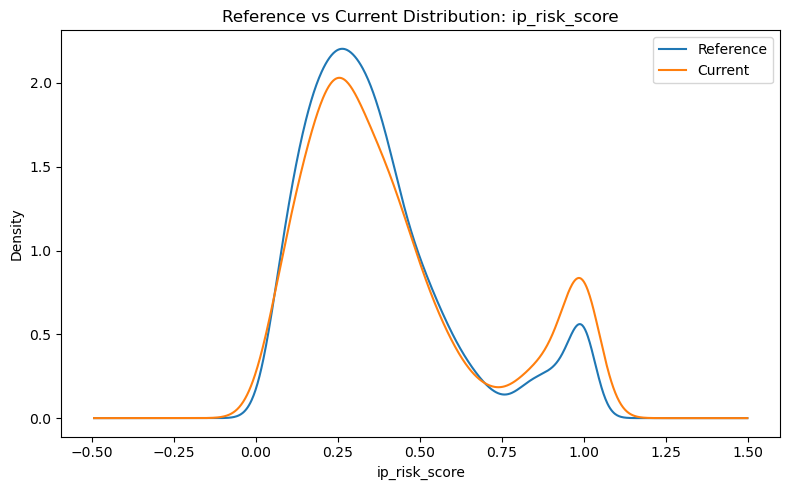

Interpretation for ip_risk_score: if the reference and current distributions look similar, the model environment is likely stable for this signal. If they are far apart, this may indicate drift and should be investigated.


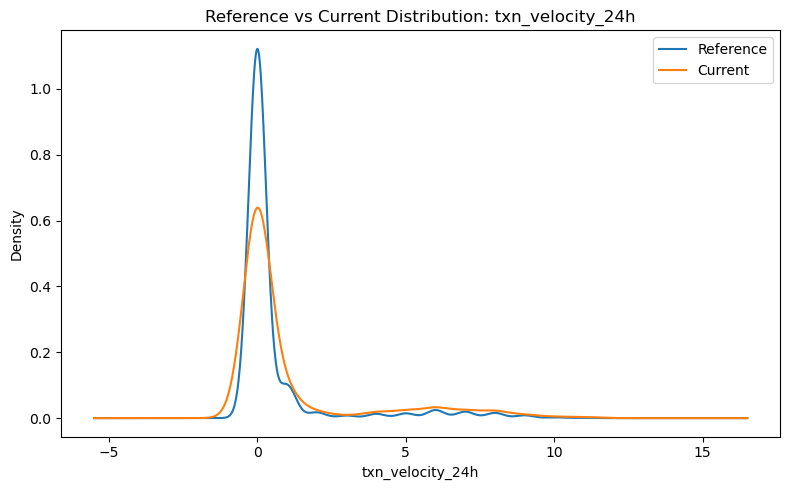

Interpretation for txn_velocity_24h: if the reference and current distributions look similar, the model environment is likely stable for this signal. If they are far apart, this may indicate drift and should be investigated.


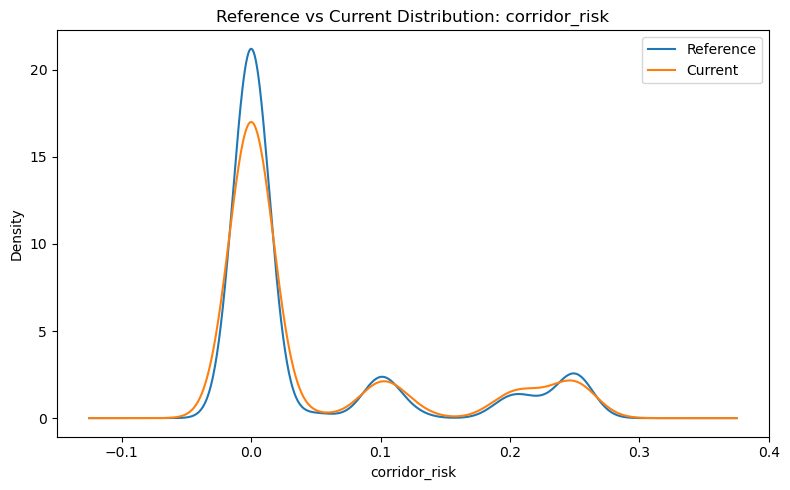

Interpretation for corridor_risk: if the reference and current distributions look similar, the model environment is likely stable for this signal. If they are far apart, this may indicate drift and should be investigated.


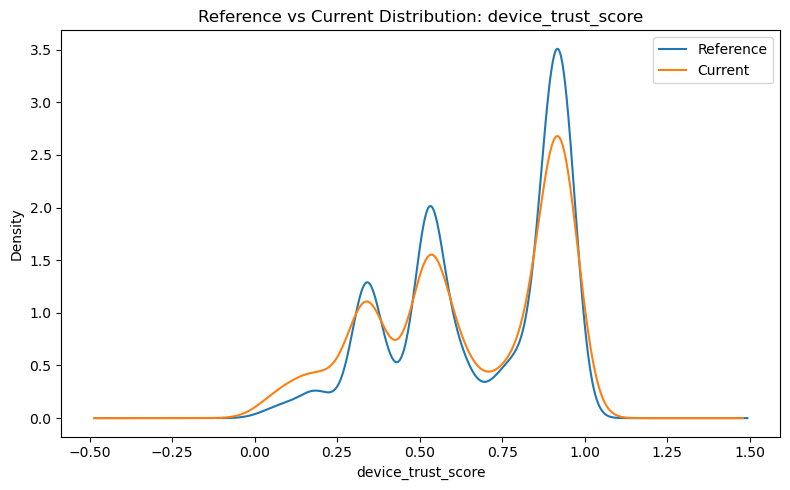

Interpretation for device_trust_score: if the reference and current distributions look similar, the model environment is likely stable for this signal. If they are far apart, this may indicate drift and should be investigated.


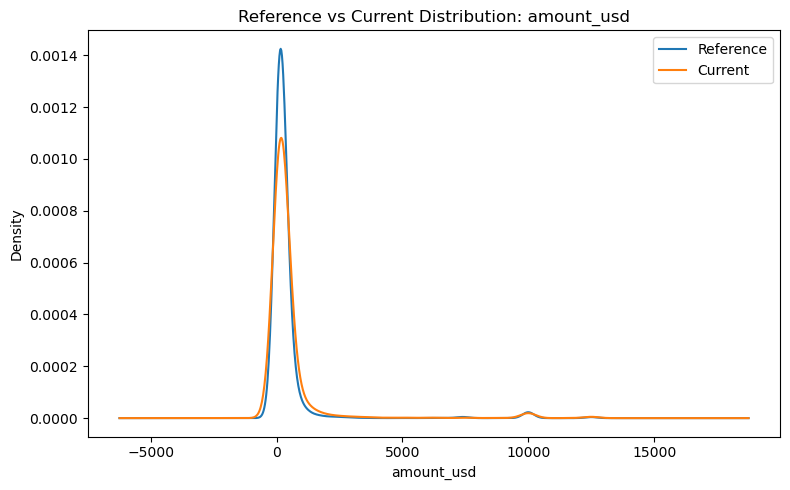

Interpretation for amount_usd: if the reference and current distributions look similar, the model environment is likely stable for this signal. If they are far apart, this may indicate drift and should be investigated.


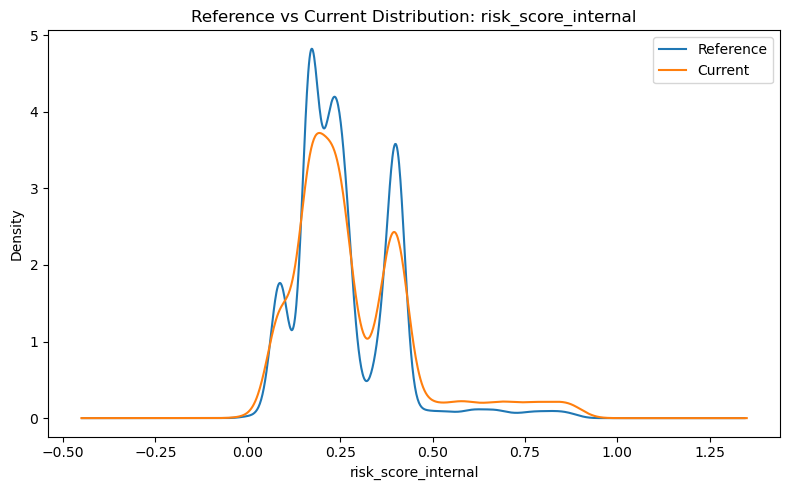

Interpretation for risk_score_internal: if the reference and current distributions look similar, the model environment is likely stable for this signal. If they are far apart, this may indicate drift and should be investigated.


{'ip_risk_score': 'C:\\Users\\sadeq\\reports\\figures\\day9\\ip_risk_score_reference_vs_current.png',
 'txn_velocity_24h': 'C:\\Users\\sadeq\\reports\\figures\\day9\\txn_velocity_24h_reference_vs_current.png',
 'corridor_risk': 'C:\\Users\\sadeq\\reports\\figures\\day9\\corridor_risk_reference_vs_current.png',
 'device_trust_score': 'C:\\Users\\sadeq\\reports\\figures\\day9\\device_trust_score_reference_vs_current.png',
 'amount_usd': 'C:\\Users\\sadeq\\reports\\figures\\day9\\amount_usd_reference_vs_current.png',
 'risk_score_internal': 'C:\\Users\\sadeq\\reports\\figures\\day9\\risk_score_internal_reference_vs_current.png'}

In [43]:
plot_features = [
    "ip_risk_score", "txn_velocity_24h", "corridor_risk",
    "device_trust_score", "amount_usd", "risk_score_internal",
]
plot_features = [feature for feature in plot_features if feature in work_df.columns]
plot_status = {}

if plt is None:
    print("Skipping plots because matplotlib is unavailable.")
else:
    for feature in plot_features:
        ref_values = pd.to_numeric(reference_df[feature], errors="coerce").dropna()
        cur_values = pd.to_numeric(current_df[feature], errors="coerce").dropna()
        if ref_values.empty or cur_values.empty:
            plot_status[feature] = "skipped_empty_values"
            continue

        plt.figure(figsize=(8, 5))
        plotted = False
        try:
            ref_values.plot(kind="kde", label="Reference")
            cur_values.plot(kind="kde", label="Current")
            plotted = True
        except Exception as exc:
            plt.clf()
            print(f"KDE failed for {feature}; using histogram instead. Detail: {exc}")
            plt.hist(ref_values, bins=30, alpha=0.5, density=True, label="Reference")
            plt.hist(cur_values, bins=30, alpha=0.5, density=True, label="Current")
            plotted = True

        if plotted:
            plt.title(f"Reference vs Current Distribution: {feature}")
            plt.xlabel(feature)
            plt.ylabel("Density")
            plt.legend()
            plt.tight_layout()
            output_path = FIGURE_DIR / f"{feature}_reference_vs_current.png"
            plt.savefig(output_path, dpi=150)
            plt.show()
            print(f"Interpretation for {feature}: if the reference and current distributions look similar, the model environment is likely stable for this signal. If they are far apart, this may indicate drift and should be investigated.")
            plt.close()
            plot_status[feature] = str(output_path)

with open(ARTIFACT_DIR / "drift_plot_status.json", "w", encoding="utf-8") as f:
    json.dump(plot_status, f, indent=2)
plot_status


## 8. Manual Drift Summary Fallback

Manual pandas drift monitoring always runs, even if Evidently works.

This fallback summary gives transparent audit evidence because every calculation is easy to inspect. It is useful for beginners, reviewers, and business stakeholders who want a readable table of what changed.

For numerical columns, it monitors reference mean, current mean, absolute change, percentage change, and missing rate change.

For categorical columns, it monitors reference top category, current top category, category change, and missing rate change.


In [44]:
rows = []

for col in numerical_features:
    ref = pd.to_numeric(reference_df[col], errors="coerce")
    cur = pd.to_numeric(current_df[col], errors="coerce")
    ref_mean = ref.mean()
    cur_mean = cur.mean()
    abs_diff = cur_mean - ref_mean
    pct_diff = np.nan if pd.isna(ref_mean) or abs(ref_mean) <= 1e-12 else (abs_diff / abs(ref_mean)) * 100
    ref_missing = ref.isna().mean()
    cur_missing = cur.isna().mean()
    drift_flag = bool((pd.notna(pct_diff) and abs(pct_diff) > 20) or ((cur_missing - ref_missing) > 0.10))
    rows.append({
        "feature": col,
        "feature_type": "numerical",
        "reference_mean": ref_mean,
        "current_mean": cur_mean,
        "absolute_difference": abs_diff,
        "percentage_difference": pct_diff,
        "reference_top_category": None,
        "current_top_category": None,
        "top_category_changed": None,
        "reference_missing_rate": ref_missing,
        "current_missing_rate": cur_missing,
        "missing_rate_increase_pp": (cur_missing - ref_missing) * 100,
        "drift_flag": drift_flag,
    })

for col in categorical_features:
    ref = reference_df[col]
    cur = current_df[col]
    ref_mode = ref.dropna().astype(str).mode()
    cur_mode = cur.dropna().astype(str).mode()
    ref_top = ref_mode.iloc[0] if len(ref_mode) else None
    cur_top = cur_mode.iloc[0] if len(cur_mode) else None
    changed = ref_top != cur_top
    ref_missing = ref.isna().mean()
    cur_missing = cur.isna().mean()
    drift_flag = bool(changed or ((cur_missing - ref_missing) > 0.10))
    rows.append({
        "feature": col,
        "feature_type": "categorical",
        "reference_mean": None,
        "current_mean": None,
        "absolute_difference": None,
        "percentage_difference": None,
        "reference_top_category": ref_top,
        "current_top_category": cur_top,
        "top_category_changed": bool(changed),
        "reference_missing_rate": ref_missing,
        "current_missing_rate": cur_missing,
        "missing_rate_increase_pp": (cur_missing - ref_missing) * 100,
        "drift_flag": drift_flag,
    })

manual_drift_summary = pd.DataFrame(rows)
manual_drift_summary.to_csv(ARTIFACT_DIR / "manual_drift_summary.csv", index=False)
display(manual_drift_summary.sort_values("drift_flag", ascending=False))


,feature,feature_type,reference_mean,current_mean,absolute_difference,percentage_difference,reference_top_category,current_top_category,top_category_changed,reference_missing_rate,current_missing_rate,missing_rate_increase_pp,drift_flag
0,amount_usd,numerical,423.490323,516.646942,93.156619,21.997343,None,None,None,0.025989,0.027719,0.172926,True
7,txn_velocity_1h,numerical,0.392190,0.722814,0.330624,84.302052,None,None,None,0.000000,0.000000,0.000000,True
8,txn_velocity_24h,numerical,0.597101,1.089552,0.492452,82.473786,None,None,None,0.000000,0.000000,0.000000,True
29,is_night_transaction,categorical,NaN,NaN,NaN,NaN,0,0,False,0.000000,0.000000,0.000000,False
28,is_weekend,categorical,NaN,NaN,NaN,NaN,0,0,False,0.000000,0.000000,0.000000,False
27,chargeback_group,categorical,NaN,NaN,NaN,NaN,No Chargeback,No Chargeback,False,0.000000,0.000000,0.000000,False
26,device_trust_band,categorical,NaN,NaN,NaN,NaN,Very High,Very High,False,0.025989,0.027719,0.172926,False
30,location_mismatch,categorical,NaN,NaN,NaN,NaN,False,False,False,0.000000,0.000000,0.000000,False
17,device_avg_trust_score,numerical,0.678796,0.644924,-0.033873,-4.990083,None,None,None,0.000261,0.000000,-0.026120,False
25,corridor_risk_band,categorical,NaN,NaN,NaN,NaN,Very Low,Very Low,False,0.000000,0.000000,0.000000,False


## 9. Model Performance Monitoring

This section loads `models/day6/best_advanced_model.joblib` and evaluates it when the `is_fraud` label exists.

Performance monitoring requires confirmed fraud labels. In real fraud systems, labels often arrive later after fraud investigation, customer dispute, or chargeback confirmation.

Metric meanings:

- **Accuracy** measures overall correctness.
- **Precision** measures alert quality.
- **Recall** measures how much actual fraud the model catches.
- **F1** balances precision and recall.
- **ROC-AUC** measures ranking quality across thresholds.
- **Average precision** is useful when fraud is rare.

Recall is critical because low recall means fraud is escaping detection.


In [45]:
MODEL_PATH = PROJECT_ROOT / "models" / "day6" / "best_advanced_model.joblib"
LABEL_COL = "is_fraud"
EXCLUDE_COLUMNS = [
    "transaction_id", "customer_id", "device_id", "ip_address", "timestamp",
    "customer_first_txn", "customer_last_txn", "weekday_name", LABEL_COL,
]

def add_monitoring_features(frame):
    out = frame.copy()
    if "timestamp" in out.columns:
        ts = pd.to_datetime(out["timestamp"], errors="coerce", utc=True)
        out["transaction_hour"] = ts.dt.hour.fillna(0).astype(int)
        out["weekday"] = ts.dt.weekday.fillna(0).astype(int)
        out["is_weekend"] = out["weekday"].isin([5, 6]).astype(int)
        out["is_night_transaction"] = out["transaction_hour"].between(0, 5).astype(int)
    if {"home_country", "ip_country"}.issubset(out.columns):
        out["country_mismatch_flag"] = (out["home_country"].astype(str) != out["ip_country"].astype(str)).astype(int)
    if {"source_currency", "dest_currency"}.issubset(out.columns):
        out["corridor"] = out["source_currency"].astype(str) + "_to_" + out["dest_currency"].astype(str)
    if "corridor_risk" in out.columns and "corridor_risk_band" not in out.columns:
        out["corridor_risk_band"] = pd.cut(pd.to_numeric(out["corridor_risk"], errors="coerce"), [-np.inf, 0.33, 0.66, np.inf], labels=["low", "medium", "high"]).astype(str)
    if "chargeback_history_count" in out.columns and "chargeback_group" not in out.columns:
        out["chargeback_group"] = pd.cut(pd.to_numeric(out["chargeback_history_count"], errors="coerce"), [-np.inf, 0, 2, np.inf], labels=["none", "some", "high"]).astype(str)
    if "device_trust_score" in out.columns and "device_trust_band" not in out.columns:
        out["device_trust_band"] = pd.cut(pd.to_numeric(out["device_trust_score"], errors="coerce"), [-np.inf, 0.30, 0.70, np.inf], labels=["low", "medium", "high"]).astype(str)
    if "txn_velocity_1h" in out.columns:
        out["high_velocity_1h_flag"] = (pd.to_numeric(out["txn_velocity_1h"], errors="coerce").fillna(0) >= 5).astype(int)
    if "txn_velocity_24h" in out.columns:
        out["high_velocity_24h_flag"] = (pd.to_numeric(out["txn_velocity_24h"], errors="coerce").fillna(0) >= 20).astype(int)
    if {"high_velocity_1h_flag", "high_velocity_24h_flag"}.issubset(out.columns):
        out["any_velocity_risk_flag"] = ((out["high_velocity_1h_flag"] == 1) | (out["high_velocity_24h_flag"] == 1)).astype(int)
    if "ip_risk_score" in out.columns:
        out["high_ip_risk_flag"] = (pd.to_numeric(out["ip_risk_score"], errors="coerce").fillna(0) >= 0.75).astype(int)
    if "device_trust_score" in out.columns:
        out["low_device_trust_flag"] = (pd.to_numeric(out["device_trust_score"], errors="coerce").fillna(1) <= 0.30).astype(int)
    if "amount_usd" in out.columns:
        out["customer_transaction_count"] = out.get("customer_transaction_count", 1)
        out["customer_total_amount"] = out.get("customer_total_amount", out["amount_usd"])
        out["customer_avg_amount"] = out.get("customer_avg_amount", out["amount_usd"])
        out["customer_max_amount"] = out.get("customer_max_amount", out["amount_usd"])
        out["customer_amount_std"] = out.get("customer_amount_std", 0)
        out["amount_to_customer_avg"] = pd.to_numeric(out["amount_usd"], errors="coerce") / pd.to_numeric(out["customer_avg_amount"], errors="coerce").replace(0, 1)
    if "account_age_days" in out.columns:
        out["customer_recency_days"] = out.get("customer_recency_days", out["account_age_days"])
    if "device_trust_score" in out.columns:
        out["device_transaction_count"] = out.get("device_transaction_count", 1)
        out["device_avg_trust_score"] = out.get("device_avg_trust_score", out["device_trust_score"])
    return out

def prepare_model_frame(frame, model):
    X = add_monitoring_features(frame).drop(columns=[col for col in EXCLUDE_COLUMNS if col in frame.columns], errors="ignore")
    expected_features = getattr(model, "feature_names_in_", None)
    if expected_features is not None:
        for col in expected_features:
            if col not in X.columns:
                X[col] = 0
        X = X[list(expected_features)]
    return X

def evaluate_period(name, period_df, model):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
    y_true = pd.to_numeric(period_df[LABEL_COL], errors="coerce").fillna(0).astype(int)
    X = prepare_model_frame(period_df, model)
    y_pred = model.predict(X)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        raw_score = model.decision_function(X)
        y_prob = 1 / (1 + np.exp(-raw_score))
    else:
        y_prob = y_pred
    return {
        "period": name,
        "rows": len(period_df),
        "fraud_rate": float(y_true.mean()),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)) if y_true.nunique() > 1 else np.nan,
        "average_precision": float(average_precision_score(y_true, y_prob)) if y_true.nunique() > 1 else np.nan,
    }

performance_status = {"completed": False, "reason": None, "model_path": str(MODEL_PATH)}
if joblib is None:
    performance_status["reason"] = "joblib is unavailable."
elif not MODEL_PATH.exists():
    performance_status["reason"] = "Saved model artifact is unavailable."
elif LABEL_COL not in work_df.columns:
    performance_status["reason"] = "True labels are unavailable. Performance monitoring requires confirmed fraud labels."
else:
    try:
        model = joblib.load(MODEL_PATH)
        performance_df = pd.DataFrame([
            evaluate_period("reference", reference_df, model),
            evaluate_period("current", current_df, model),
        ])
        performance_df.to_csv(ARTIFACT_DIR / "model_performance_monitoring.csv", index=False)
        display(performance_df)
        performance_status["completed"] = True
    except Exception as exc:
        performance_status["reason"] = str(exc)
        print("Model performance monitoring could not be completed:", exc)

with open(ARTIFACT_DIR / "model_performance_status.json", "w", encoding="utf-8") as f:
    json.dump(performance_status, f, indent=2)
print(performance_status)


,period,rows,fraud_rate,accuracy,precision,recall,f1,roc_auc,average_precision
0,reference,7657,0.071438,0.943581,0.561366,0.961609,0.708895,0.991820,0.930192
1,current,3283,0.134633,0.944258,0.723661,0.947964,0.820764,0.980758,0.962513


{'completed': True, 'reason': None, 'model_path': 'C:\\Users\\sadeq\\models\\day6\\best_advanced_model.joblib'}


## 10. Performance Decay Flags

A model can still run technically but become less useful.

Example:

```text
Original recall:        95%
After deployment:       80%
```

This indicates model decay because the model is missing more fraud than before. If precision drops, analysts may receive more false alerts. These flags turn performance monitoring into clear action signals.


In [46]:
flags = []
perf_path = ARTIFACT_DIR / "model_performance_monitoring.csv"
if perf_path.exists():
    perf = pd.read_csv(perf_path).set_index("period")
    if {"reference", "current"}.issubset(perf.index):
        ref_perf = perf.loc["reference"]
        cur_perf = perf.loc["current"]
        for metric in ["recall", "precision", "f1", "average_precision"]:
            change_pp = (cur_perf[metric] - ref_perf[metric]) * 100
            flags.append({
                "metric": metric,
                "reference_value": ref_perf[metric],
                "current_value": cur_perf[metric],
                "change_percentage_points": change_pp,
                "decay_flag": bool(change_pp < -10),
                "rule": f"Flag if {metric} drops by more than 10 percentage points",
            })
else:
    flags.append({
        "metric": "performance_monitoring",
        "reference_value": None,
        "current_value": None,
        "change_percentage_points": None,
        "decay_flag": False,
        "rule": "Skipped because performance monitoring was unavailable",
    })

performance_decay_flags = pd.DataFrame(flags)
performance_decay_flags.to_csv(ARTIFACT_DIR / "performance_decay_flags.csv", index=False)
display(performance_decay_flags)


,metric,reference_value,current_value,change_percentage_points,decay_flag,rule
0,recall,0.961609,0.947964,-1.364497,False,Flag if recall drops by more than 10 percentag...
1,precision,0.561366,0.723661,16.229542,False,Flag if precision drops by more than 10 percen...
2,f1,0.708895,0.820764,11.186908,False,Flag if f1 drops by more than 10 percentage po...
3,average_precision,0.930192,0.962513,3.232024,False,Flag if average_precision drops by more than 1...


## 11. Fraud Prevalence Monitoring

Fraud prevalence means the percentage of transactions that are fraud.

A sudden increase may indicate a new fraud campaign or changing fraud tactics. It can also indicate seasonal effects, labelling delay, or a shift in customer mix.


In [47]:
if LABEL_COL in work_df.columns:
    fraud_prevalence = pd.DataFrame([
        {"period": "reference", "rows": len(reference_df), "fraud_rate": pd.to_numeric(reference_df[LABEL_COL], errors="coerce").fillna(0).mean()},
        {"period": "current", "rows": len(current_df), "fraud_rate": pd.to_numeric(current_df[LABEL_COL], errors="coerce").fillna(0).mean()},
    ])
    fraud_prevalence.to_csv(ARTIFACT_DIR / "fraud_prevalence_monitoring.csv", index=False)
    display(fraud_prevalence)
else:
    print("Fraud prevalence monitoring requires an is_fraud label column.")


,period,rows,fraud_rate
0,reference,7657,0.071438
1,current,3283,0.134633


## 12. Escalation Rules

Escalation rules convert model monitoring into business action. They tell the team what to do when a risk signal triggers.


In [48]:
escalation_rules_df = pd.DataFrame([
    {"Signal": "Data drift on 3 or more key features", "Threshold": ">= 3 key features flagged", "Severity": "Medium", "Action": "Analyst review of affected features, channels, countries, and corridors", "Owner": "Fraud Analytics"},
    {"Signal": "Recall drop > 10 percentage points", "Threshold": "> 10 percentage points", "Severity": "High", "Action": "Start retraining investigation and review missed fraud cases", "Owner": "ML Engineer"},
    {"Signal": "Precision drop > 10 percentage points", "Threshold": "> 10 percentage points", "Severity": "High", "Action": "Review alert quality, false positives, and decision threshold", "Owner": "Fraud Operations"},
    {"Signal": "Fraud rate doubles in a corridor", "Threshold": "2x reference fraud rate", "Severity": "High", "Action": "Targeted rule review and corridor investigation", "Owner": "Fraud Operations"},
    {"Signal": "Chargebacks increase > 25% month-on-month", "Threshold": "> 25% increase", "Severity": "High", "Action": "Fraud operations escalation and case review", "Owner": "Fraud Operations"},
    {"Signal": "API health check model_loaded false", "Threshold": "Any production occurrence", "Severity": "Critical", "Action": "Engineering incident, restore model artifact, and rollback if needed", "Owner": "Platform Engineering"},
])
escalation_rules_df.to_csv(ARTIFACT_DIR / "escalation_rules.csv", index=False)
display(escalation_rules_df)


,Signal,Threshold,Severity,Action,Owner
0,Data drift on 3 or more key features,>= 3 key features flagged,Medium,"Analyst review of affected features, channels,...",Fraud Analytics
1,Recall drop > 10 percentage points,> 10 percentage points,High,Start retraining investigation and review miss...,ML Engineer
2,Precision drop > 10 percentage points,> 10 percentage points,High,"Review alert quality, false positives, and dec...",Fraud Operations
3,Fraud rate doubles in a corridor,2x reference fraud rate,High,Targeted rule review and corridor investigation,Fraud Operations
4,Chargebacks increase > 25% month-on-month,> 25% increase,High,Fraud operations escalation and case review,Fraud Operations
5,API health check model_loaded false,Any production occurrence,Critical,"Engineering incident, restore model artifact, ...",Platform Engineering


## 13. Create or Improve Retraining Playbook

The playbook is the operational guide for what the team should do after monitoring detects risk.

It is not code; it is a decision process. It explains who responds, what thresholds matter, when retraining should happen, and how rollback works.


In [49]:
playbook_text = '# NovaPay Retraining Playbook\n\n## 1. Purpose\n\nThis playbook explains how NovaPay should monitor the fraud detection model after deployment and decide when to retrain, recalibrate, escalate, or roll back the model.\n\nThe goal is to keep the model reliable as fraud tactics, customer behaviour, transaction corridors, devices, and risk signals change over time.\n\n## 2. Why Monitoring Is Needed\n\nDeployment is not the end of a machine learning project. Fraud models are trained on historical behaviour, but fraud tactics can change after the model goes live.\n\nMonitoring is needed because it helps NovaPay detect when live transactions stop looking like the data used during training. If this happens, the model may become less reliable.\n\n## 3. Key Monitoring Signals\n\nKey signals include transaction amount, IP risk score, device trust score, internal risk score, transaction velocity, corridor risk, location mismatch, new-device usage, KYC tier, country, channel, fraud probability, prediction distribution, precision, recall, F1 score, fraud rate, and chargebacks.\n\n## 4. Data Drift Monitoring\n\nData drift means current transaction data has changed compared with reference data. For example, if the current average `ip_risk_score` is much higher than before, NovaPay may be seeing more traffic from risky network environments.\n\nRecommended response:\n\n- Review features flagged for drift.\n- Break down drift by corridor, country, and channel.\n- Check whether recent fraud cases match the drifted segment.\n- Escalate if multiple critical features drift together.\n\n## 5. Model Performance Monitoring\n\nModel performance monitoring checks whether the model still predicts well on newer labelled data.\n\nImportant metrics:\n\n- Accuracy measures overall correctness.\n- Precision measures alert quality.\n- Recall measures how much actual fraud the model catches.\n- F1 balances precision and recall.\n- Average precision is useful when fraud is rare.\n\nIn fraud detection, recall is especially important because missed fraud can create direct financial loss.\n\n## 6. Fraud Prevalence Monitoring\n\nFraud prevalence is the percentage of transactions that are fraud. A sudden increase may indicate a new attack, a seasonal pattern, a labelling delay, or a change in customer mix.\n\nNovaPay should monitor fraud prevalence overall and by corridor, country, channel, KYC tier, and device status.\n\n## 7. Escalation Rules\n\n| Signal | Threshold | Severity | Action | Owner |\n|---|---:|---|---|---|\n| Data drift on key features | 3 or more key features flagged | Medium | Analyst review of affected features and segments | Fraud Analytics |\n| Recall drop | More than 10 percentage points | High | Start retraining investigation and missed-fraud review | ML Engineer |\n| Precision drop | More than 10 percentage points | High | Review false positives and alert thresholds | Fraud Operations |\n| Fraud rate doubles in a corridor | 2x reference rate | High | Targeted corridor rule review | Fraud Operations |\n| Chargebacks increase | More than 25% month-on-month | High | Fraud operations escalation | Fraud Operations |\n| API health check fails | `model_loaded` is false | Critical | Engineering incident and rollback if needed | Platform Engineering |\n\n## 8. Quarterly Retraining Cadence\n\nNovaPay should retrain the model every quarter.\n\n| Period | Activity | Output |\n|---|---|---|\n| Month 1 | Collect new labelled data from investigations, chargebacks, and approved transactions | Updated labelled dataset |\n| Month 2 | Validate labels, investigate drift, review features, and identify changing fraud patterns | Monitoring report and feature review |\n| Month 3 | Retrain challenger models, evaluate, approve, and deploy | Approved model candidate |\n\n## 9. Emergency Retraining Triggers\n\nEmergency retraining should be investigated if recall drops sharply, precision drops sharply, fraud losses increase, chargebacks increase by more than 25% month-on-month, several critical features drift together, fraud rate doubles in a key corridor, or fraud operations report a repeated new fraud pattern.\n\n## 10. Model Approval Criteria\n\nA retrained model should be approved only if recall is stable or improved, precision remains acceptable, average precision improves or remains stable, false positives remain operationally manageable, results are stable across key segments, explainability review is acceptable, and API tests pass.\n\n## 11. Deployment Checklist\n\n- Save the new model artifact.\n- Save the threshold artifact if the threshold changed.\n- Update model version information.\n- Run API health checks.\n- Run `/score` tests with low-risk, medium-risk, and high-risk payloads.\n- Run automated tests.\n- Confirm the rollback model is available.\n- Document metrics and approval decisions.\n- Notify fraud operations and engineering stakeholders.\n\n## 12. Rollback Plan\n\nRollback means returning to the previous approved model if the new model causes problems.\n\nRollback steps:\n\n1. Restore the previous approved model artifact.\n2. Restart the API service.\n3. Confirm `/health` returns `model_loaded: true`.\n4. Run sample `/score` requests.\n5. Monitor predictions and error logs.\n6. Record the incident and root cause.\n\n## 13. Stakeholder Responsibilities\n\n| Stakeholder | Responsibilities |\n|---|---|\n| ML Engineer | Builds monitoring, retrains models, evaluates performance, manages model artifacts |\n| Fraud Analyst | Reviews drift, investigates emerging fraud patterns, validates suspicious segments |\n| Fraud Operations | Reviews alert quality, confirms chargebacks, manages manual review decisions |\n| Platform Engineering | Deploys API, monitors service health, manages rollback |\n| Product or Risk Lead | Approves model changes based on business risk and customer impact |\n\n## 14. Documentation Requirements\n\nEach monitoring or retraining cycle should save the data drift report, manual drift summary, model performance file, performance decay flags, fraud prevalence report, escalation rules, model approval notes, deployment checklist, and rollback notes if rollback occurs.\n'
root_playbook_path = PROJECT_ROOT / "retraining_playbook.md"
artifact_playbook_path = ARTIFACT_DIR / "retraining_playbook.md"
root_playbook_path.write_text(playbook_text, encoding="utf-8")
artifact_playbook_path.write_text(playbook_text, encoding="utf-8")
print("Created/updated:", root_playbook_path)
print("Saved copy:", artifact_playbook_path)


Created/updated: C:\Users\sadeq\retraining_playbook.md
Saved copy: C:\Users\sadeq\reports\artifacts\day9\retraining_playbook.md


## Reflection: What early warning signals might indicate new or emerging fraud tactics?

Early warning signals include:

- rising IP risk scores
- more location mismatches
- more new-device transactions
- sudden changes in transaction corridors
- higher transaction velocity
- increasing chargebacks
- fraud rate rising in specific channels or countries
- recall dropping
- precision dropping
- model confidence becoming unstable

These signs may show that fraudsters are changing behaviour in ways the model did not see during training.


## Assessment: One Drift Metric and Recommended Response

A useful drift metric is the **percentage change in average `ip_risk_score`**.

This metric compares the average `ip_risk_score` in the reference period with the current period. If the current average increases by more than 20%, it may indicate that more transactions are coming from risky network environments.

Recommended response:

- review affected channels and countries
- check fraud cases in the same period
- monitor recall and precision
- escalate if drift persists
- consider retraining if performance also declines


## Final Day 9 Summary

Training created the model. Deployment exposed the model to live-style transaction behaviour. Monitoring protects the model by checking whether the world around it is changing.

Reference and current data were compared. EvidentlyAI report generation was attempted with version-aware compatibility for Evidently 0.7+ and older APIs. If Evidently could not create an HTML report, the reason was logged and pandas manual drift monitoring remained the main evidence.

Manual drift summary was created as fallback and audit evidence. Missing values were monitored as drift signals. Drift plots were displayed inline and saved. Model performance monitoring was completed when labels and the model were available. Performance decay flags and escalation rules were created. A retraining playbook was created in the project root and copied into Day 9 artifacts. NovaPay should use quarterly retraining with emergency retraining triggers.


## 17. Final Checklist

The checklist below shows PASS/FAIL for the required Day 9 deliverables. It is designed for a final review before submission.


In [50]:
check_items = [
    ("Data loaded", "PASS" if "df" in globals() and len(df) > 0 else "FAIL"),
    ("Reference/current split created", "PASS" if "reference_df" in globals() and "current_df" in globals() and len(reference_df) > 0 and len(current_df) > 0 else "FAIL"),
    ("Missing monitoring completed", "PASS" if (ARTIFACT_DIR / "missing_value_summary.csv").exists() else "FAIL"),
    ("Evidently attempted", "PASS" if (ARTIFACT_DIR / "evidently_run_status.json").exists() else "FAIL"),
    ("Evidently status logged", "PASS" if (ARTIFACT_DIR / "evidently_run_status.json").exists() else "FAIL"),
    ("Manual drift completed", "PASS" if (ARTIFACT_DIR / "manual_drift_summary.csv").exists() else "FAIL"),
    ("Visual plots displayed and saved", "PASS" if (ARTIFACT_DIR / "drift_plot_status.json").exists() and any(FIGURE_DIR.glob("*_reference_vs_current.png")) else "FAIL"),
    ("Performance monitoring completed or explained", "PASS" if (ARTIFACT_DIR / "model_performance_monitoring.csv").exists() or (ARTIFACT_DIR / "model_performance_status.json").exists() else "FAIL"),
    ("Performance decay flags created", "PASS" if (ARTIFACT_DIR / "performance_decay_flags.csv").exists() else "FAIL"),
    ("Escalation rules created", "PASS" if (ARTIFACT_DIR / "escalation_rules.csv").exists() else "FAIL"),
    ("Retraining playbook created", "PASS" if (PROJECT_ROOT / "retraining_playbook.md").exists() and (ARTIFACT_DIR / "retraining_playbook.md").exists() else "FAIL"),
]

checklist_df = pd.DataFrame([{"item": item, "status": status} for item, status in check_items])
display(checklist_df)

with open(ARTIFACT_DIR / "day9_final_checklist.json", "w", encoding="utf-8") as f:
    json.dump(checklist_df.to_dict(orient="records"), f, indent=2)


,item,status
0,Data loaded,PASS
1,Reference/current split created,PASS
2,Missing monitoring completed,PASS
3,Evidently attempted,PASS
4,Evidently status logged,PASS
5,Manual drift completed,PASS
6,Visual plots displayed and saved,PASS
7,Performance monitoring completed or explained,PASS
8,Performance decay flags created,PASS
9,Escalation rules created,PASS


In [51]:
from pathlib import Path

for file in Path(".").rglob("data_drift_report.html"):
    print(file)

reports\monitoring\day9\data_drift_report.html
